In [2]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time
import SoftImpute
import TabCSDI


In [3]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from SoftImpute import softimpute, cv_softimpute
from TabCSDI import TabCSDIImputer


In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time


In [5]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [6]:
data = fetch_openml(name="Energy_efficiency", version=2, as_frame=True)
X_full = data.data.copy()

In [7]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.1 KB
None


Scalling the data to min-max scale

In [8]:
#scaler = MinMaxScaler() #data [0,1] #giving better result
#X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)


scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [20]:
GroundTruth = X_full.copy()
X = X_full.copy()

print(GroundTruth)

     relative_compactness  surface_area  wall_area  roof_area  overall_height  \
0                2.041777     -1.785875  -0.561951  -1.470077             1.0   
1                2.041777     -1.785875  -0.561951  -1.470077             1.0   
2                2.041777     -1.785875  -0.561951  -1.470077             1.0   
3                2.041777     -1.785875  -0.561951  -1.470077             1.0   
4                1.284979     -1.229239   0.000000  -1.198678             1.0   
..                    ...           ...        ...        ...             ...   
763             -1.174613      1.275625   0.561951   0.972512            -1.0   
764             -1.363812      1.553943   1.123903   0.972512            -1.0   
765             -1.363812      1.553943   1.123903   0.972512            -1.0   
766             -1.363812      1.553943   1.123903   0.972512            -1.0   
767             -1.363812      1.553943   1.123903   0.972512            -1.0   

     orientation  glazing_a

Converting GroundTruth to tensor

In [10]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [11]:
GroundTruth.nunique()

relative_compactness         12
surface_area                 12
wall_area                     7
roof_area                     4
overall_height                2
orientation                   4
glazing_area                  4
glazing_area_distribution     6
dtype: int64

In [12]:
print("relative_compactness",GroundTruth['relative_compactness'].unique())
print("surface_area",GroundTruth['surface_area'].unique())
print("wall_area",GroundTruth['wall_area'].unique())
print("roof_area",GroundTruth['roof_area'].unique())
print("overall_height",GroundTruth["overall_height"].unique())
print("orientation",GroundTruth['orientation'].unique())
print("glazing_area",GroundTruth['glazing_area'].unique())
print("glazing_area_distribution",GroundTruth['glazing_area_distribution'].unique())

relative_compactness [ 2.04177671  1.28497917  0.90658039  0.52818162  0.24438254 -0.03941654
 -0.22861593 -0.51241501 -0.70161439 -0.98541347 -1.17461286 -1.36381225]
surface_area [-1.78587489 -1.22923856 -0.95092039 -0.67260223 -0.39428407 -0.1159659
  0.16235226  0.44067043  0.71898859  0.99730676  1.27562492  1.55394308]
wall_area [-0.56195149  0.          0.56195149  2.24780595 -1.68585446 -1.12390297
  1.12390297]
roof_area [-1.47007664 -1.19867787 -0.65588035  0.97251224]
overall_height [ 1. -1.]
orientation [-1.34164079 -0.4472136   0.4472136   1.34164079]
glazing_area [-1.76044698 -1.00932293  0.11736313  1.2440492 ]
glazing_area_distribution [-1.81457514 -1.16939287 -0.5242106   0.12097168  0.76615395  1.41133622]


Dependecies for MAR & MNAR

In [13]:
mean_relative = GroundTruth["relative_compactness"].mean()
median_surface = GroundTruth["surface_area"].median()
mean_wall = GroundTruth["wall_area"].mean()
median_roof = GroundTruth["roof_area"].median()
mean_height = GroundTruth["overall_height"].mean()
median_orientation = GroundTruth["orientation"].median()
mean_glazing = GroundTruth["glazing_area"].mean()
median_glazing_dist = GroundTruth["glazing_area_distribution"].median()



dependencies_mar = {
    "relative_compactness": {
        "influencers": ["surface_area"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["surface_area"] > median_surface else 0.1
    },
    "surface_area": {
        "influencers": ["wall_area"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["wall_area"] < mean_wall else 0.1
    },
    "wall_area": {
        "influencers": ["roof_area"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["roof_area"] > median_roof else 0.1
    },
    "roof_area": {
        "influencers": ["overall_height"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["overall_height"] < mean_height else 0.1
    },
    "overall_height": {
        "influencers": ["orientation"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["orientation"] > median_orientation else 0.1
    },
    "orientation": {
        "influencers": ["glazing_area"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["glazing_area"] < mean_glazing else 0.1
    },
    "glazing_area": {
        "influencers": ["glazing_area_distribution"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["glazing_area_distribution"] > median_glazing_dist else 0.1
    },
    "glazing_area_distribution": {
        "influencers": ["relative_compactness"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["relative_compactness"] < mean_relative else 0.1
    }
}


In [14]:
dependencies_mnar = {
    "relative_compactness": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["relative_compactness"] > mean_relative else 0.1
    },
    "surface_area": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["surface_area"] < median_surface else 0.1
    },
    "wall_area": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["wall_area"] > mean_wall else 0.1
    },
    "roof_area": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["roof_area"] < median_roof else 0.1
    },
    "overall_height": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["overall_height"] > mean_height else 0.1
    },
    "orientation": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["orientation"] < median_orientation else 0.1
    },
    "glazing_area": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["glazing_area"] > mean_glazing else 0.1
    },
    "glazing_area_distribution": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["glazing_area_distribution"] < median_glazing_dist else 0.1
    }
}


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [15]:
missing_rates = [10,30,50,70,90]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 400, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    OT_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae  # mean over runs
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=80, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mcar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=16,
                               hidden_dims=[128, 64], K=10, epochs=1500)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=1500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-S  (single-fit -> Run=1)
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=16,
                          hidden_dims=[128, 64], K=10, epochs=1500)
    mean_miwaes, std_miwaes = miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaes[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-S (single-fit -> Run=1)
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=1500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gains[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-U (single-fit -> Run=1)
    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=16,
                          hidden_dims=[128, 64], K=5, epochs=1500)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaeu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-U (single-fit -> Run=1)
    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=1500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gainu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI
    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,      # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mcar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_tab[missing_mask.values].flatten(),
                       imputed_std_tab[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI-S (single-fit -> Run=1)
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
        epochs=400,
        nsamples=5,          # how many posterior draws to average
        num_steps=1000,      # diffusion timesteps
        timeemb=64, featureemb=64,
        channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
    )
    tabS.fit(miss_mcar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_tabS[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_tabS[missing_mask.values].flatten(),
                       std_tabS[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "TabCSDI-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_results_with_all_missing_values.csv", index=False)


10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/400] loss=0.998692
[  40/400] loss=0.374214
[  80/400] loss=0.362484
[ 120/400] loss=0.295850
[ 160/400] loss=0.312048
[ 200/400] loss=0.312419
[ 240/400] loss=0.265625
[ 280/400] loss=0.258836
[ 320/400] loss=0.231339
[ 360/400] loss=0.252797
[ 400/400] loss=0.233259
Run 2...
[   1/400] loss=1.002580
[  40/400] loss=0.328641
[  80/400] loss=0.376514
[ 120/400] loss=0.338138
[ 160/400] loss=0.316429
[ 200/400] loss=0.280503
[ 240/400] loss=0.248104
[ 280/400] loss=0.254013
[ 320/400] loss=0.241173
[ 360/400] loss=0.242998
[ 400/400] loss=0.240606
Run 3...
[   1/400] loss=1.027791
[  40/400] loss=0.368866
[  80/400] loss=0.371898
[ 120/400] loss=0.317676
[ 160/400] loss=0.31

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=40, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=16,
                            hidden_dims=[128, 64], K=10, epochs=1500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=1500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mcar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,      # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4 
        )
                imputed = imputer.fit_transform(miss_mcar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...
[   1/400] loss=0.999350
[  40/400] loss=0.360986
[  80/400] loss=0.353495
[ 120/400] loss=0.349386
[ 160/400] loss=0.310598
[ 200/400] loss=0.289844
[ 240/400] loss=0.291507
[ 280/400] loss=0.232524
[ 320/400] loss=0.264772
[ 360/400] loss=0.264744
[ 400/400] loss=0.244536
Run 2...
[   1/400] loss=1.008294
[  40/400] 

: 

Multiple Sample Run

In [17]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mcar = []
runs=3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    missing_mask = miss_mcar.isna()

    for run in range(runs):  # Correct
        for sample in samples:
            print(sample)

            # MIWAE-S (tuned for Energy)
            print("MIWAE-S")
            miwae = MIWAEImputer(
                input_dim=miss_mcar.shape[1],
                latent_dim=16,
                hidden_dims=[128, 64],
                K=10,
                epochs=1500
            )
            mean_miwae, std_miwae = miwae.fit_transform_std(
                miss_mcar, return_std=True, inference_K=sample
            )
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_miwae[missing_mask.values].flatten(),
                std_miwae[missing_mask.values].flatten()
            ):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # GAIN-S (tuned for Energy)
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=1500, batch_size=512)
            _ = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_gain[missing_mask.values].flatten(),
                std_gain[missing_mask.values].flatten()
            ):
                results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # TabCSDI-S (tuned for Energy)
            print("TabCSDI-S")
            tabS = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,        # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4
            )
            tabS.fit(miss_mcar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_tabS[missing_mask.values].flatten(),
                std_tabS[missing_mask.values].flatten()
            ):
                results_mcar.append({
                    "Algorithm": "TabCSDI-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_results_sample_runs.csv",
    index=False
)


30
10
MIWAE-S
GAIN-S
TabCSDI-S
[   1/400] loss=0.986431
[  40/400] loss=0.342888
[  80/400] loss=0.369493
[ 120/400] loss=0.336314
[ 160/400] loss=0.335136
[ 200/400] loss=0.280947
[ 240/400] loss=0.255623
[ 280/400] loss=0.260599
[ 320/400] loss=0.256431
[ 360/400] loss=0.232628
[ 400/400] loss=0.245595
30
MIWAE-S
GAIN-S
TabCSDI-S
[   1/400] loss=1.024332
[  40/400] loss=0.312809
[  80/400] loss=0.310816
[ 120/400] loss=0.363245
[ 160/400] loss=0.371003
[ 200/400] loss=0.276931
[ 240/400] loss=0.281488
[ 280/400] loss=0.285861
[ 320/400] loss=0.262721
[ 360/400] loss=0.266873
[ 400/400] loss=0.249192
50
MIWAE-S
GAIN-S
TabCSDI-S
[   1/400] loss=0.939422
[  40/400] loss=0.339119
[  80/400] loss=0.320300
[ 120/400] loss=0.327774
[ 160/400] loss=0.273779
[ 200/400] loss=0.281876
[ 240/400] loss=0.274923
[ 280/400] loss=0.235522
[ 320/400] loss=0.259198
[ 360/400] loss=0.244784
[ 400/400] loss=0.217469
70
MIWAE-S
GAIN-S
TabCSDI-S
[   1/400] loss=1.005996
[  40/400] loss=0.362931
[  80/400]

## MAR

In [15]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X, missing_rate=missing_rate, dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 400, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    OT_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae  # mean over runs
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=80, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=16,
                               hidden_dims=[128, 64], K=10, epochs=1500)
        X_imputed_miwae = imputer.fit_transform(miss_mar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=1500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-S  (single-fit -> Run=1)
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=16,
                          hidden_dims=[128, 64], K=10, epochs=1500)
    mean_miwaes, std_miwaes = miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaes[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-S (single-fit -> Run=1)
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=1500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gains[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-U (single-fit -> Run=1)
    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=16,
                          hidden_dims=[128, 64], K=5, epochs=1500)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaeu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-U (single-fit -> Run=1)
    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=1500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gainu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI
    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,      # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_tab[missing_mask.values].flatten(),
                       imputed_std_tab[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI-S (single-fit -> Run=1)
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
        epochs=400,
        nsamples=5,          # how many posterior draws to average
        num_steps=1000,      # diffusion timesteps
        timeemb=64, featureemb=64,
        channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
    )
    tabS.fit(miss_mar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_tabS[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_tabS[missing_mask.values].flatten(),
                       std_tabS[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "TabCSDI-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/400] loss=0.980224
[  40/400] loss=0.341072
[  80/400] loss=0.354887
[ 120/400] loss=0.342869
[ 160/400] loss=0.317201
[ 200/400] loss=0.314070
[ 240/400] loss=0.269100
[ 280/400] loss=0.252468
[ 320/400] loss=0.245725
[ 360/400] loss=0.265360
[ 400/400] loss=0.234940
Run 2...
[   1/400] loss=1.040703
[  40/400] loss=0.371255
[  80/400] loss=0.378500
[ 120/400] loss=0.334346
[ 160/400] loss=0.323860
[ 200/400] loss=0.284144
[ 240/400] loss=0.294311
[ 280/400] loss=0.263685
[ 320/400] loss=0.305223
[ 360/400] loss=0.222261
[ 400/400] loss=0.249871
Run 3...
[   1/400] loss=1.002190
[  40/400] loss=0.355752
[  80/400] loss=0.334639
[ 120/400] loss=0.364103
[ 160/400] loss=0.33

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=40, sample_posterior=True, random_state=42)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=16,
                            hidden_dims=[128, 64], K=10, epochs=1500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=1500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,        # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
        
        )
                imputed = imputer.fit_transform(miss_mar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng()
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mar = []
runs=3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    missing_mask = miss_mar.isna()

    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(
                input_dim=miss_mar.shape[1],
                latent_dim=16,
                hidden_dims=[128, 64],
                K=10,
                epochs=1500
            )
            mean_miwae, std_miwae = miwae.fit_transform_std(
                miss_mar, return_std=True, inference_K=sample
            )

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "MIWAE-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # GAIN-S
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=1500, batch_size=512)
            _ = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            print("TabCSDI-S")
            tabS = TabCSDIImputer(
                epochs=400,
                nsamples=5,          # how many posterior draws to average
                num_steps=1000,      # diffusion timesteps
                timeemb=64, featureemb=64,
                channels=64, layers=4, nheads=4,
                seed=None
            )
            tabS.fit(miss_mar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=sample)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "TabCSDI-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

df_results = pd.DataFrame(results_mar)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_results_sample_runs.csv",
    index=False
)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


## MNAR

In [16]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mnar = []
result_mae = []

for missing_rate in missing_rates:

    # genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate, dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    # missing mask
    missing_mask = miss_mnar.isna()

    # OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=400, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    OT_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae  # mean over runs
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    # MICE
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=80, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # SoftImpute
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mnar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mnar.copy()
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=16,
                               hidden_dims=[128, 64], K=10, epochs=1500)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=1500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-S (single-fit -> Run=1)
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=16,
                          hidden_dims=[128, 64], K=10, epochs=1500)
    mean_miwaes, std_miwaes = miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaes[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-S (single-fit -> Run=1)
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=1500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gains[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-U (single-fit -> Run=1)
    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=16,
                          hidden_dims=[128, 64], K=5, epochs=1500)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaeu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-U (single-fit -> Run=1)
    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=1500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gainu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI
    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,      # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mnar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_tab[missing_mask.values].flatten(),
                       imputed_std_tab[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI-S (single-fit -> Run=1)
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
        epochs=400,
        nsamples=5,          # how many posterior draws to average
        num_steps=1000,      # diffusion timesteps
        timeemb=64, featureemb=64,
        channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
    )
    tabS.fit(miss_mnar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_tabS[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_tabS[missing_mask.values].flatten(),
                       std_tabS[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "TabCSDI-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/400] loss=0.975622
[  40/400] loss=0.334157
[  80/400] loss=0.346832
[ 120/400] loss=0.346692
[ 160/400] loss=0.327161
[ 200/400] loss=0.357275
[ 240/400] loss=0.271277
[ 280/400] loss=0.256659
[ 320/400] loss=0.256413
[ 360/400] loss=0.234918
[ 400/400] loss=0.240104
Run 2...
[   1/400] loss=0.988609
[  40/400] loss=0.357535
[  80/400] loss=0.312949
[ 120/400] loss=0.361455
[ 160/400] loss=0.309611
[ 200/400] loss=0.296727
[ 240/400] loss=0.285025
[ 280/400] loss=0.226355
[ 320/400] loss=0.231968
[ 360/400] loss=0.251270
[ 400/400] loss=0.238867
Run 3...
[   1/400] loss=1.032667
[  40/400] loss=0.359392
[  80/400] loss=0.335480
[ 120/400] loss=0.318443
[ 160/400] loss=0.33

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              
            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=40, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             
            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=16,
                            hidden_dims=[128, 64], K=10, epochs=1500)
                imputed = imputer.fit_transform(X_missing)
               
            elif algo == "GAIN":
                imputer = GAINImputer(epochs=1500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mnar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
            epochs=400,
            nsamples=2,          # how many posterior draws to average
            num_steps=1000,        # diffusion timesteps
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=None
        )
                imputed = imputer.fit_transform(miss_mnar.to_numpy()) 
                
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng()
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mnar = []
runs=3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate, dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    missing_mask = miss_mnar.isna()

    for run in range(runs):  # Correct
        for sample in samples:
            print(sample)

            # MIWAE-S (tuned for Energy)
            print("MIWAE-S")
            miwae = MIWAEImputer(
                input_dim=miss_mnar.shape[1],
                latent_dim=16,
                hidden_dims=[128, 64],
                K=10,
                epochs=1500
            )
            mean_miwae, std_miwae = miwae.fit_transform_std(
                miss_mnar, return_std=True, inference_K=sample
            )
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_miwae[missing_mask.values].flatten(),
                std_miwae[missing_mask.values].flatten()
            ):
                results_mnar.append({
                    "Algorithm": "MIWAE-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # GAIN-S (tuned; fit before sampling)
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=1500, batch_size=512)
            _ = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_gain[missing_mask.values].flatten(),
                std_gain[missing_mask.values].flatten()
            ):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # TabCSDI-S (tuned; seed=None as requested)
            print("TabCSDI-S")
            tabS = TabCSDIImputer(
                epochs=400,
                nsamples=5,          # posterior draws averaged internally
                num_steps=1000,      # diffusion timesteps
                timeemb=64, featureemb=64,
                channels=64, layers=4, nheads=4,
                seed=None
            )
            tabS.fit(miss_mnar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=sample)
            for t, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                mean_tabS[missing_mask.values].flatten(),
                std_tabS[missing_mask.values].flatten()
            ):
                results_mnar.append({
                    "Algorithm": "TabCSDI-S",
                    "run": run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_results_sample_runs.csv",
    index=False
)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


# Visualization

## MCAR

Calibration curve for all algorithms

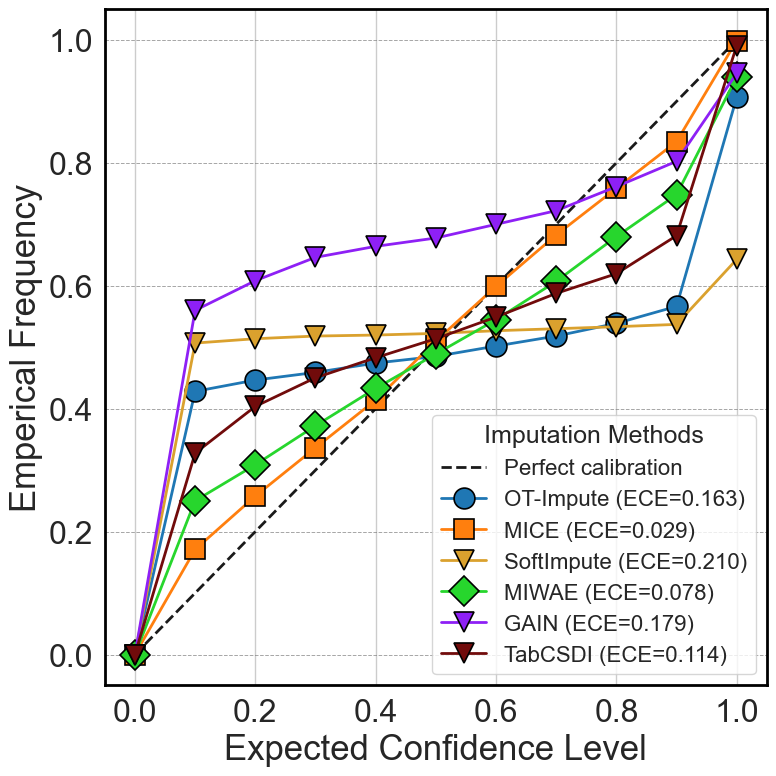

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

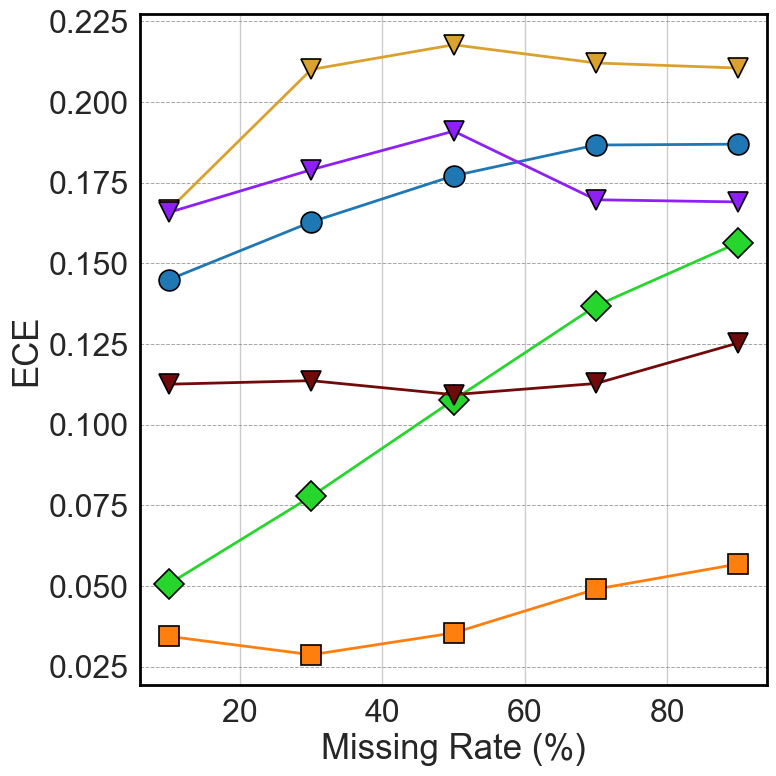

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S" or algo == "TabCSDI-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
#plt.legend(ncol=3,title="Imputation Methods",loc='center',bbox_to_anchor=(0.5,0.65),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MCAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

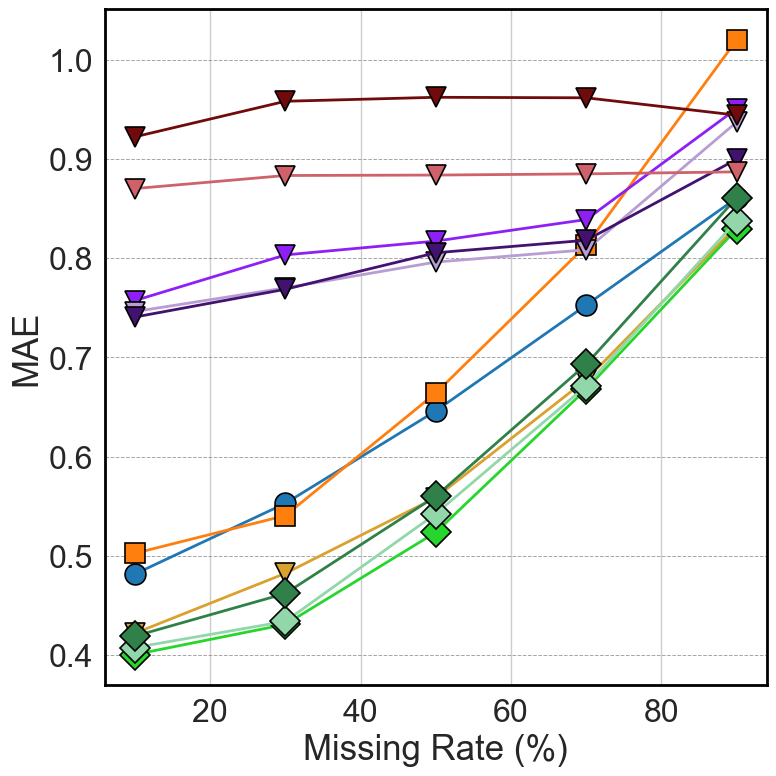

In [5]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=3,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
#ax.set_ylim(0.08, 0.30)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MCAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


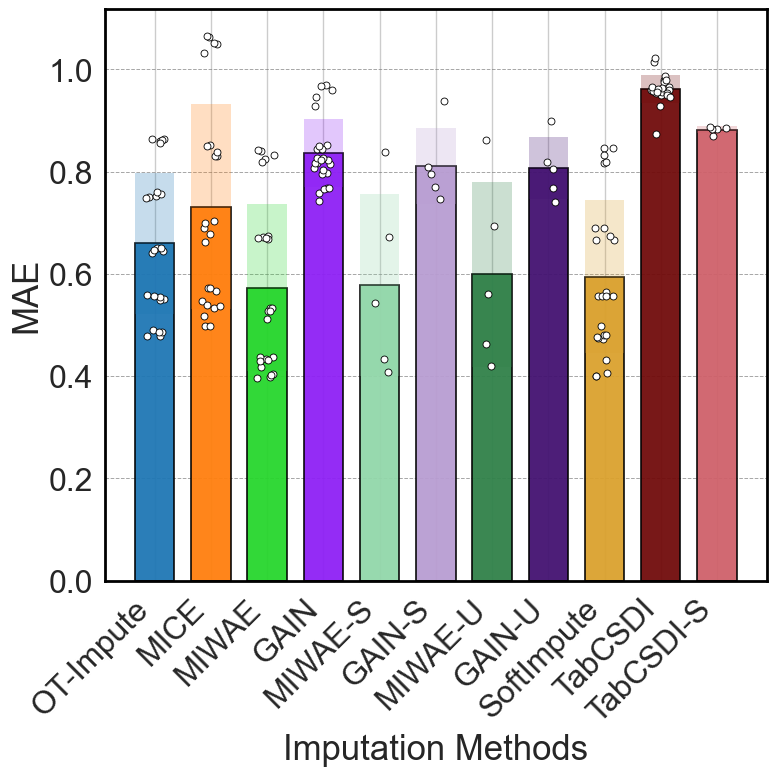

'C:\\Users\\zhossai3\\Desktop\\Uncertainty\\imputation_Uncertainty\\Output\\results\\Energy_MCAR_MAE_Bar_30.pdf'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

# === Load your uploaded file (30% missingness only) ===
file_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_mae.csv"
df = pd.read_csv(file_path)

# Ignore any rows that contain the word "mean" (case-insensitive)
df = df[~df.apply(lambda row: row.astype(str).str.contains("mean", case=False).any(), axis=1)].copy()

# === Keep the same visual style / sizes you shared ===
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# === Your color palette (same mapping as before) ===
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4"},
    "MICE":        {"color": "#ff7f0e"},
    "MIWAE":       {"color": "#27d62d"},
    "GAIN":        {"color": "#8e20f5"},
    "MIWAE-S":     {"color": "#92d7aa"},
    "GAIN-S":      {"color": "#b89dd2"},
    "MIWAE-U":     {"color": "#308149"},
    "GAIN-U":      {"color": "#431271"},
    "SoftImpute":  {"color": "#DAA12E"},
    "TabCSDI":     {"color": "#710B0B"},
    "TabCSDI-S":   {"color": "#CF616A"},
}

# Compute per-algorithm stats
grouped = df.groupby("Algorithm")
summary = grouped["MAE"].agg(["mean", "std"]).reset_index()

# Keep order as palette
ordered_algos = [a for a in algo_styles.keys() if a in summary["Algorithm"].values]
summary = summary.set_index("Algorithm").loc[ordered_algos].reset_index()

# === Plot ===
fig = plt.figure(figsize=(8, 8))
ax = plt.gca()

bar_width = 0.7
x = np.arange(len(summary))
colors = [algo_styles[a]["color"] for a in summary["Algorithm"]]

# Bars (means)
bars = ax.bar(x, summary["mean"], width=bar_width, color=colors, edgecolor="black", linewidth=1.2, alpha=0.95)

# Shaded bands: mean ± std as translucent rectangles over each bar
for i, row in summary.iterrows():
    mean = row["mean"]
    std = row["std"]
    algo = row["Algorithm"]
    color = algo_styles[algo]["color"]
    
    if np.isnan(std):
        continue  # skip if only one run
    
    lower = max(mean - std, 0)
    height = 2*std
    rect = Rectangle(
        (x[i] - bar_width/2, lower),
        bar_width, height,
        linewidth=0,
        facecolor=color,
        alpha=0.25
    )
    ax.add_patch(rect)

# Overlay individual run dots with slight jitter for visibility
rng = np.random.default_rng(42)
for i, algo in enumerate(summary["Algorithm"]):
    runs = grouped.get_group(algo)["MAE"].values
    jitter = rng.uniform(-bar_width*0.25, bar_width*0.25, size=len(runs))
    ax.plot(x[i] + jitter, runs, 'o', markersize=5, markeredgecolor="black", markeredgewidth=0.6,
            markerfacecolor="white", linestyle="None", zorder=3)

# Labels and ticks
ax.set_xlabel("Imputation Methods", fontsize=x_label_fontsize)
ax.set_ylabel("MAE", fontsize=y_label_fontsize)
ax.set_xticks(x)
ax.set_xticklabels(summary["Algorithm"], rotation=45, ha="right")

# Borders (black edges) — same as your ECE style
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Y grid
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path_pdf = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_MCAR_MAE_Bar_30.pdf"
plt.savefig(save_path_pdf, format="pdf", bbox_inches="tight")
plt.show()

save_path_pdf


ECE VS Run Number 30% MCAR

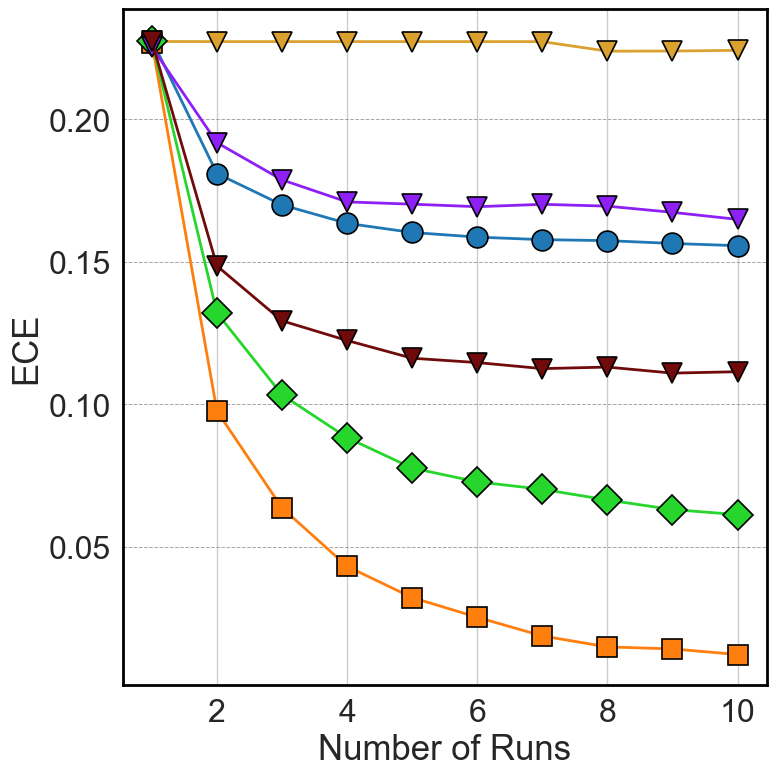

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_results_progressive_multiiple_run.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
#plt.legend(title="Imputation Methods", loc='upper right',bbox_to_anchor=(0.9,0.89),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MCAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MCAR ECE VS Sample 

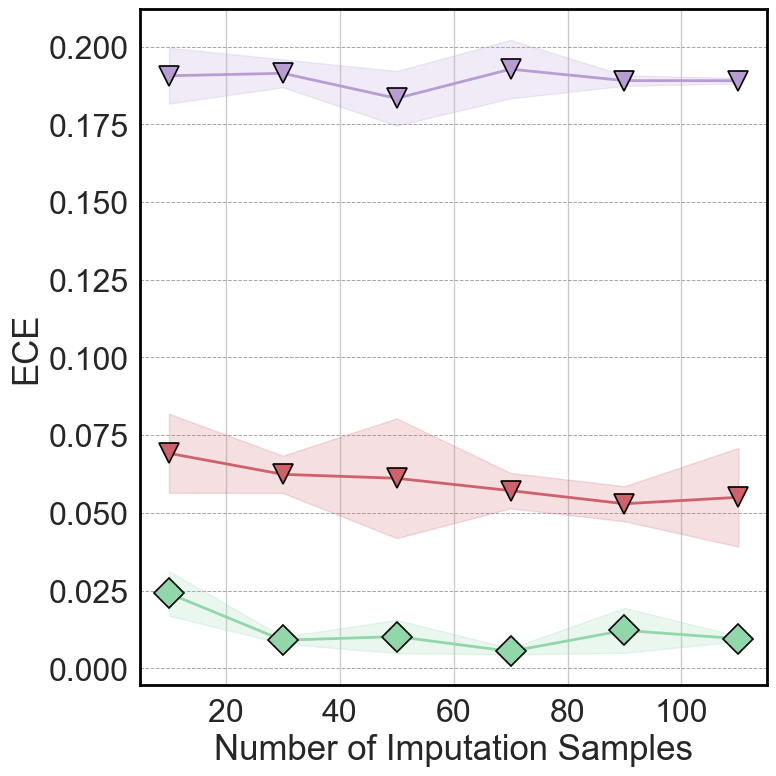

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MCAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

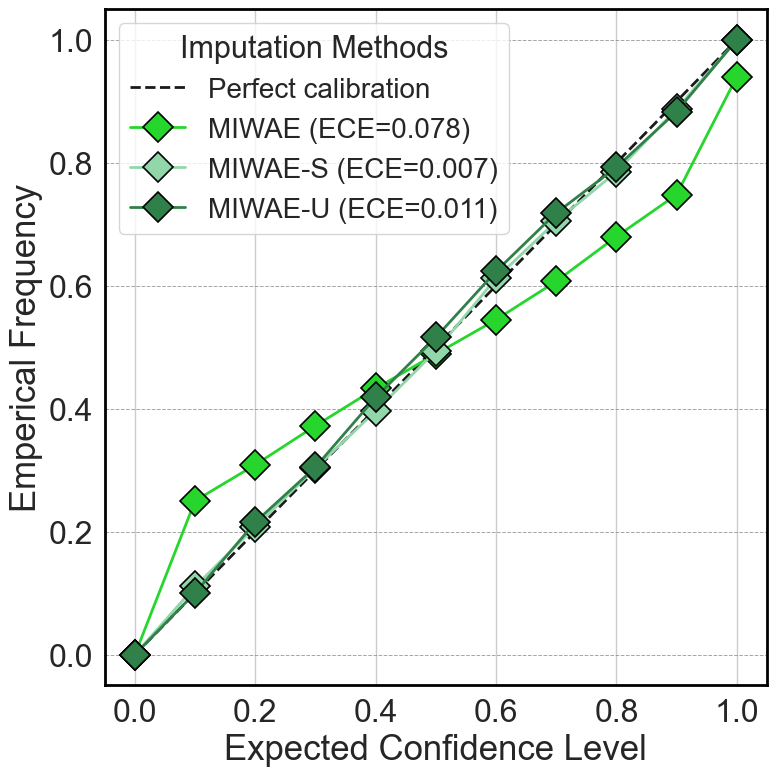

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mcar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

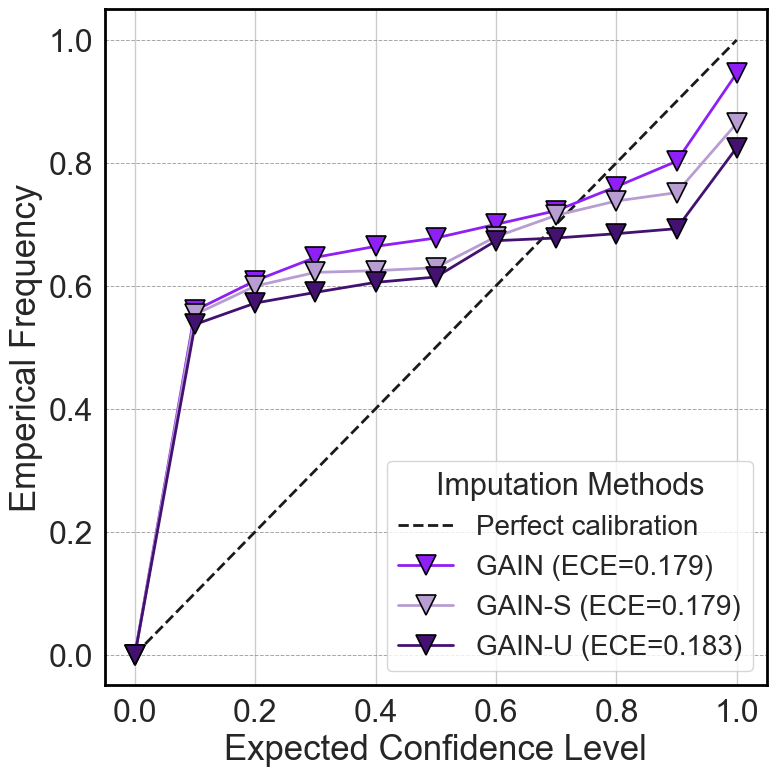

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mcar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



### TabCSDI Comparision

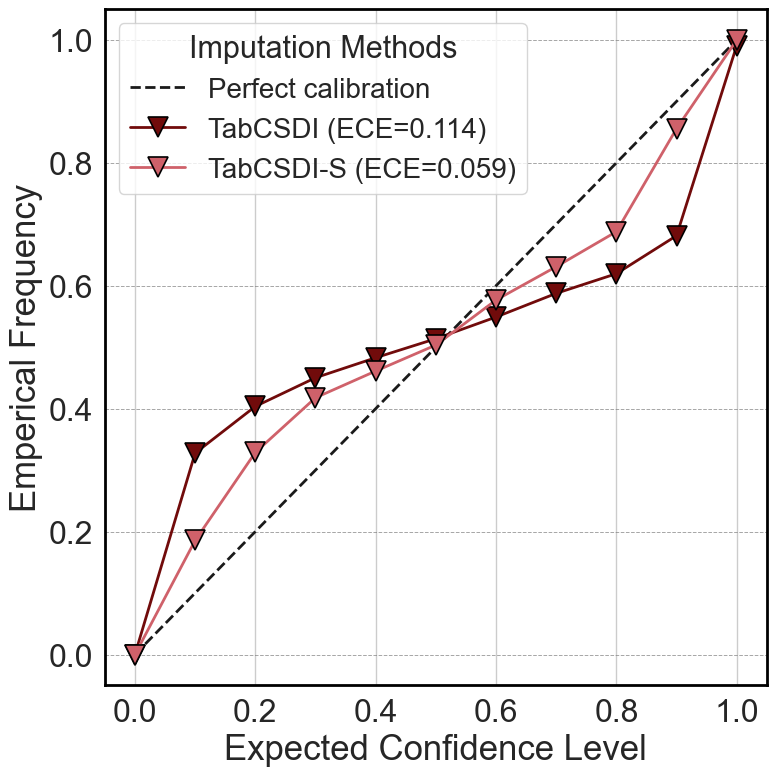

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mcar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MAR

Calibration curve for all algorithms

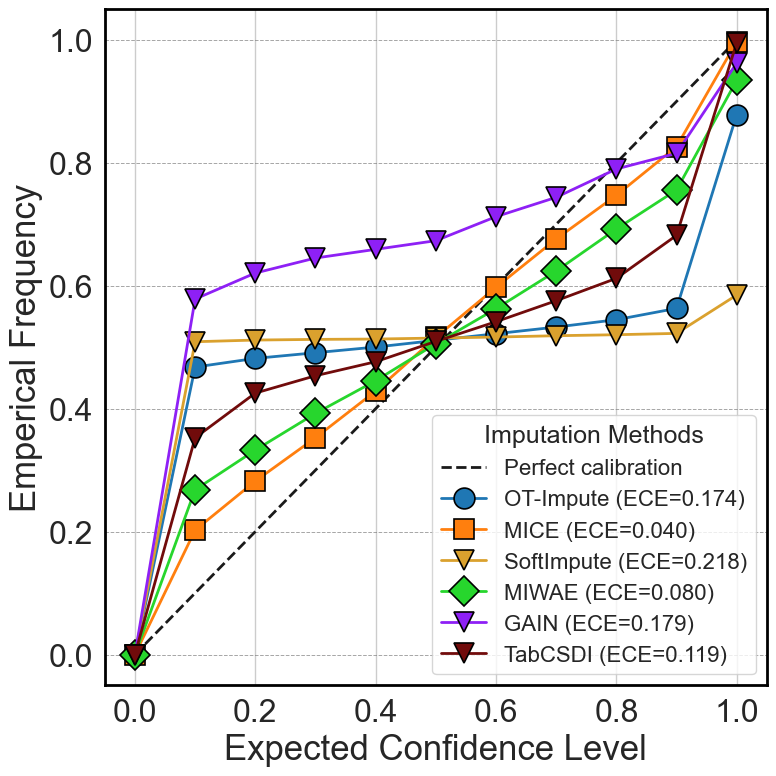

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

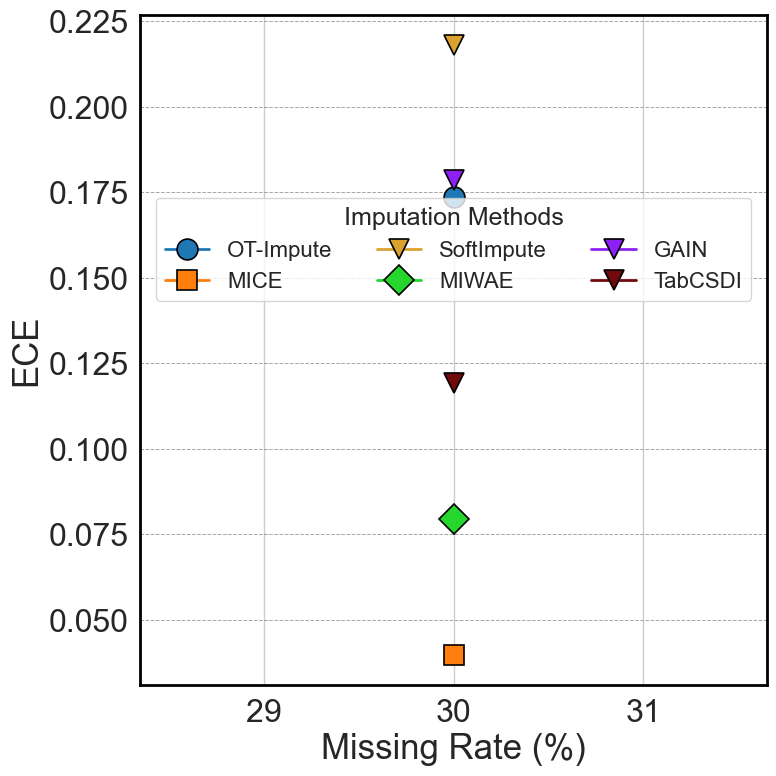

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S" or algo == "TabCSDI-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=3,title="Imputation Methods",loc='center',bbox_to_anchor=(0.5,0.65),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

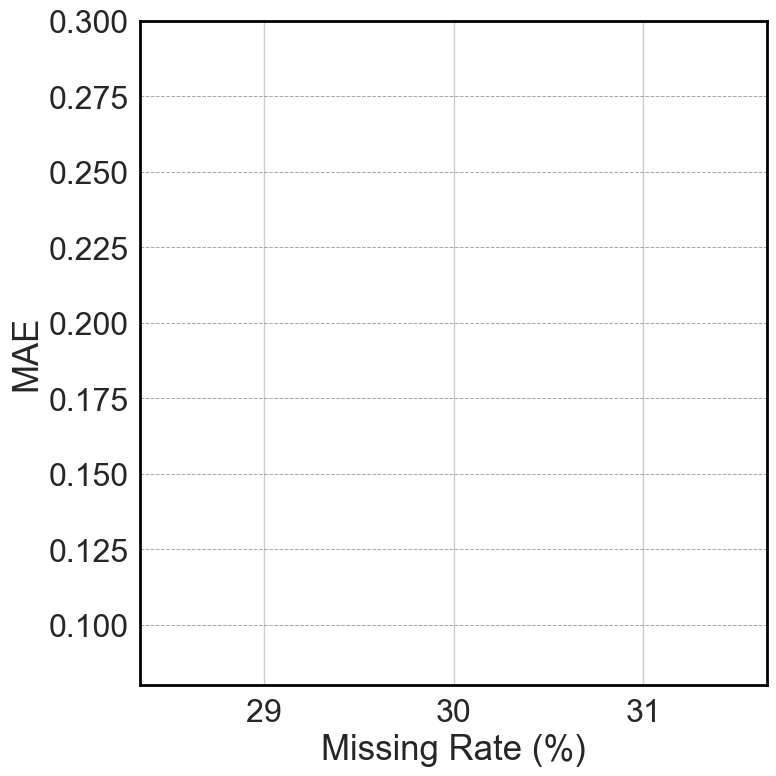

In [13]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=3,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.30)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MAR

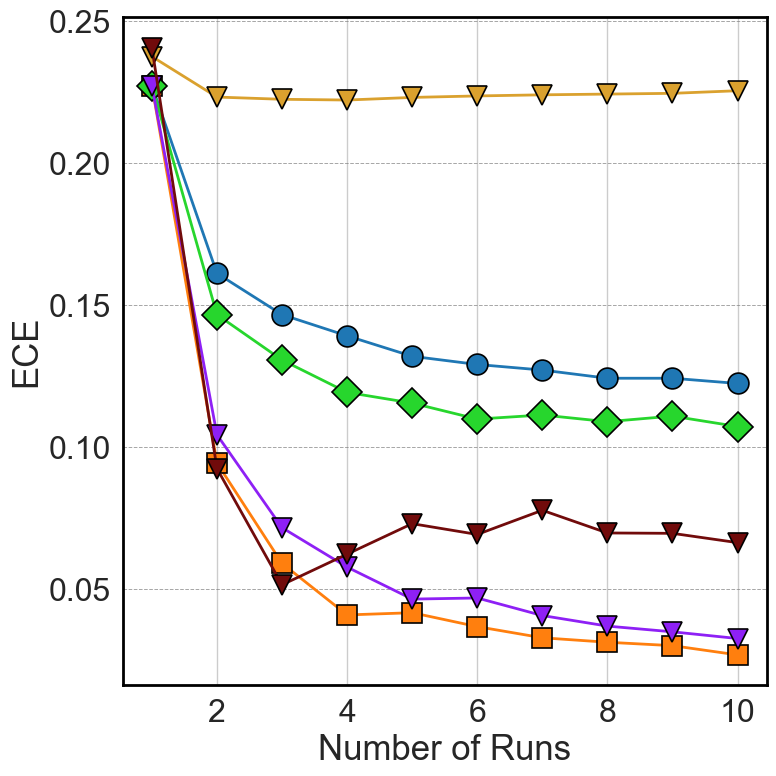

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_results_progressive_multiiple_run.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
#plt.legend(title="Imputation Methods", loc='upper right',bbox_to_anchor=(0.9,0.89),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MAR ECE VS Sample 

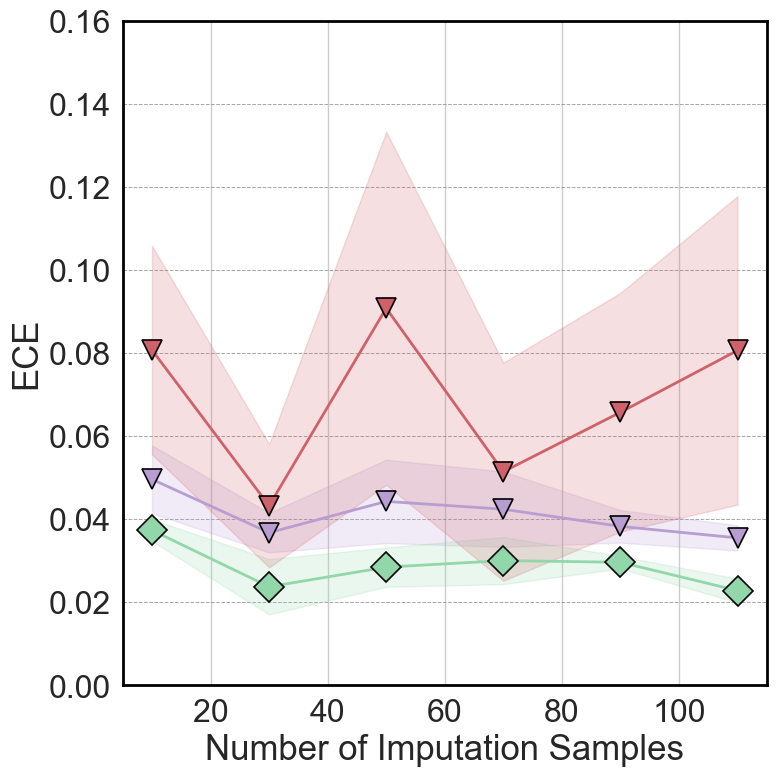

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

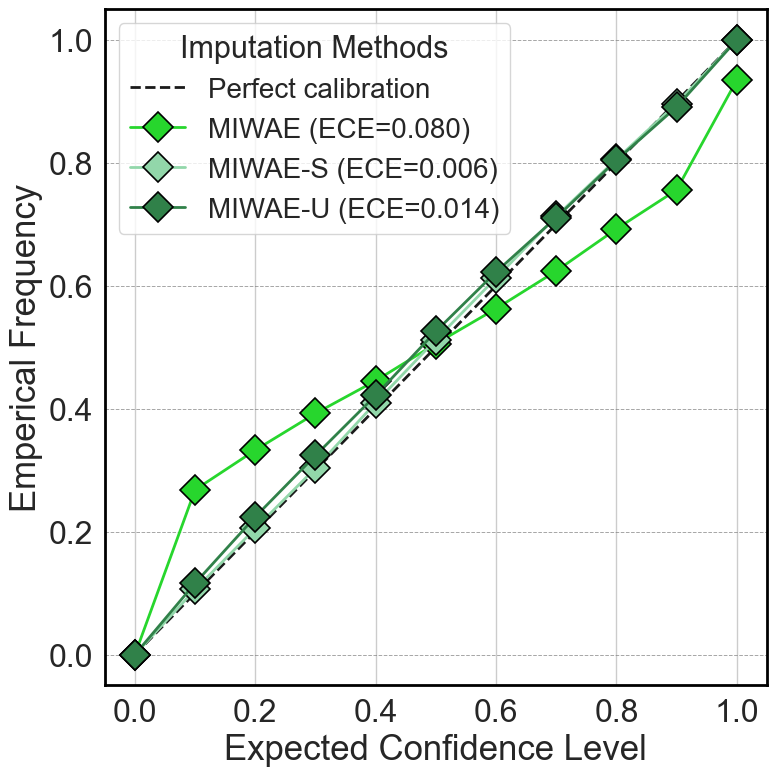

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

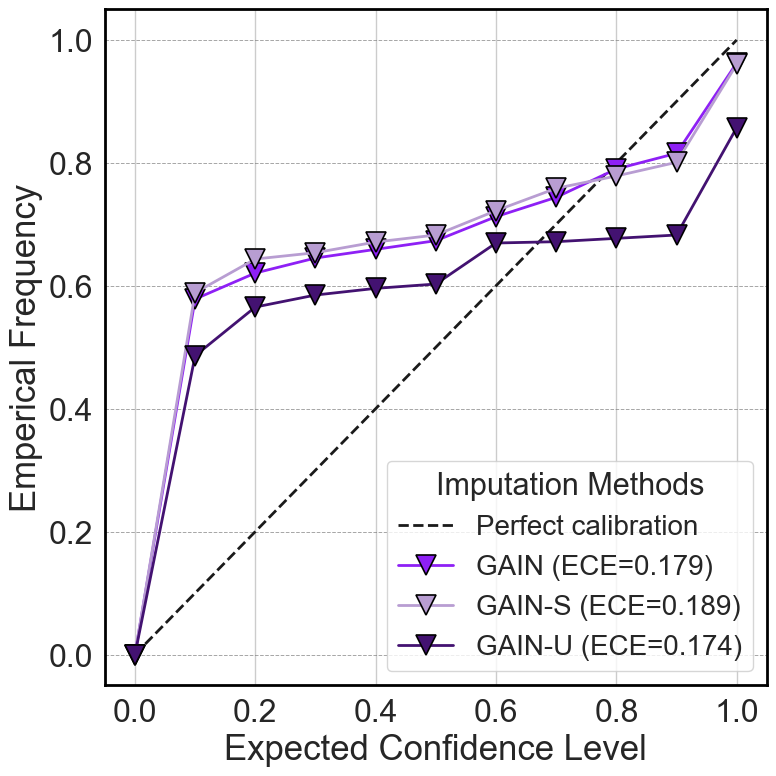

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



### TabCSDI Comparision

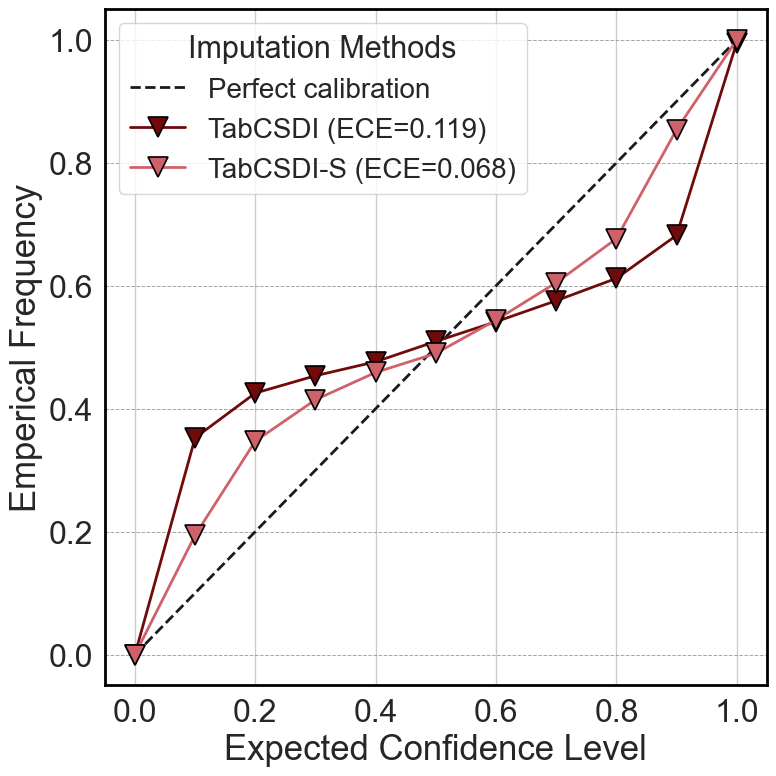

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MNAR

Calibration curve for all algorithms

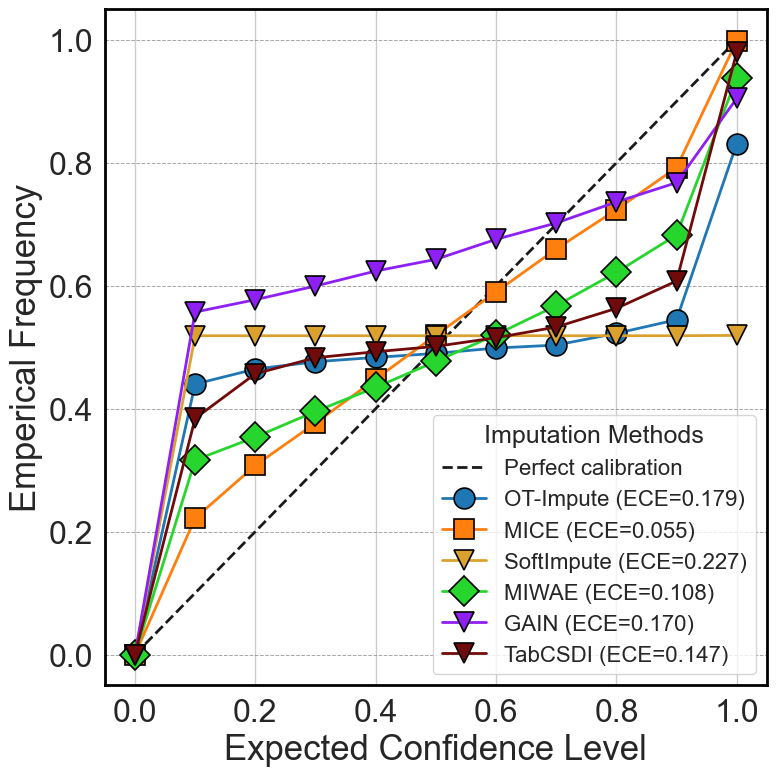

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MNAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

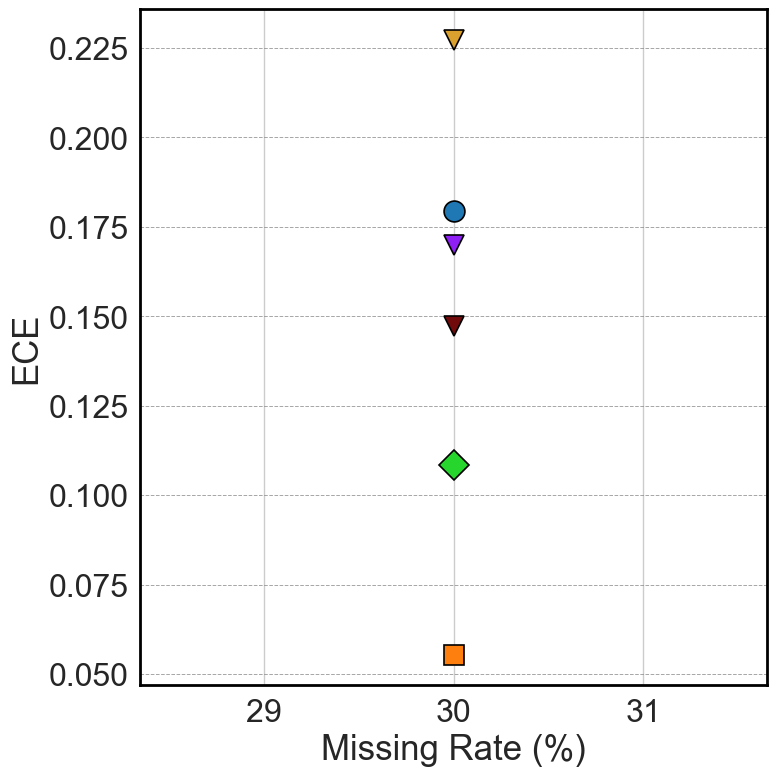

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S" or algo == "TabCSDI-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
#plt.legend(ncol=3,title="Imputation Methods",loc='center',bbox_to_anchor=(0.5,0.65),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MNAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

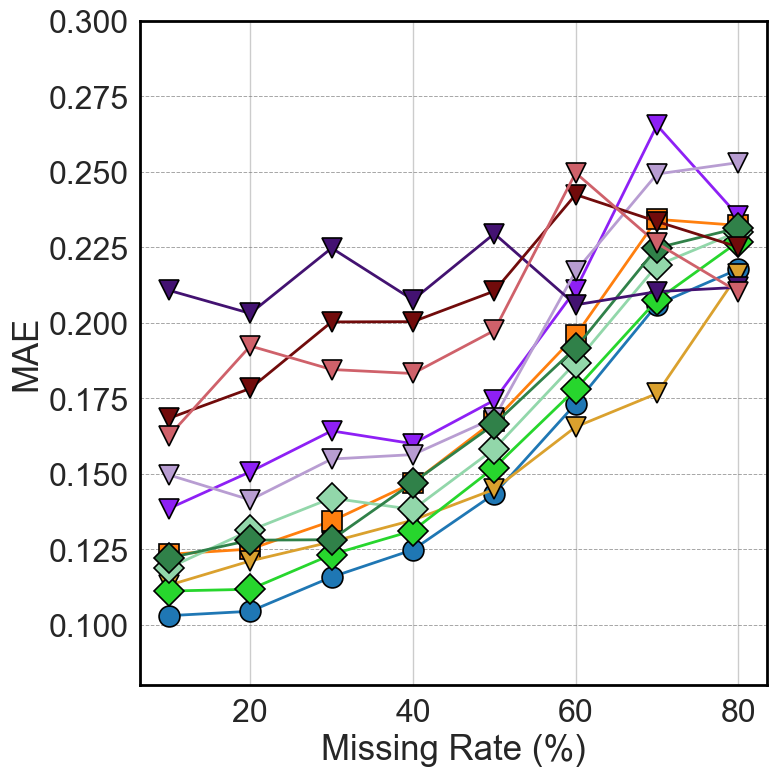

In [ ]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=3,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.30)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MNAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MNAR

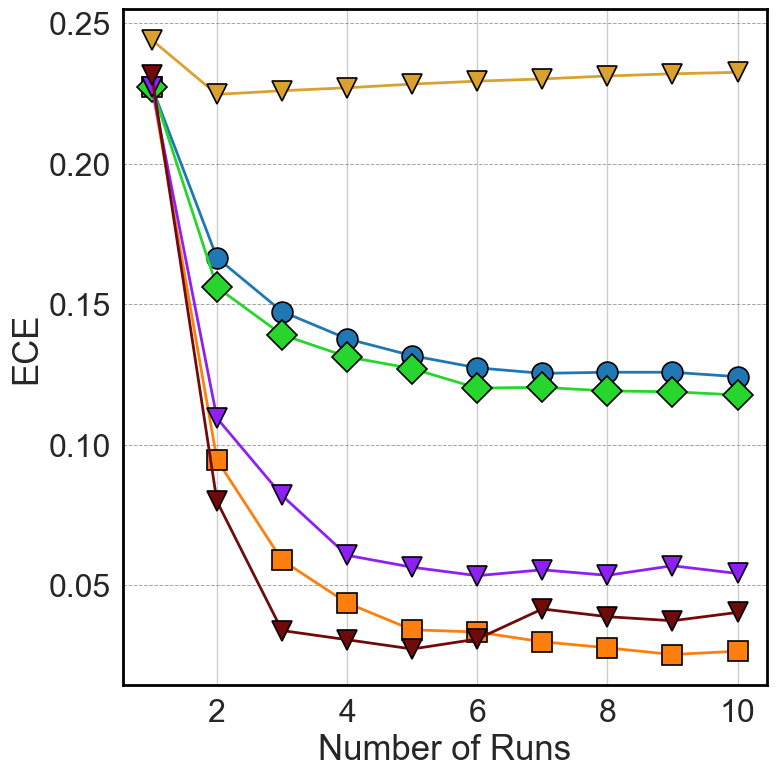

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_results_progressive_multiiple_run.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
#plt.legend(title="Imputation Methods", loc='upper right',bbox_to_anchor=(0.9,0.89),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MNAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MNAR ECE VS Sample 

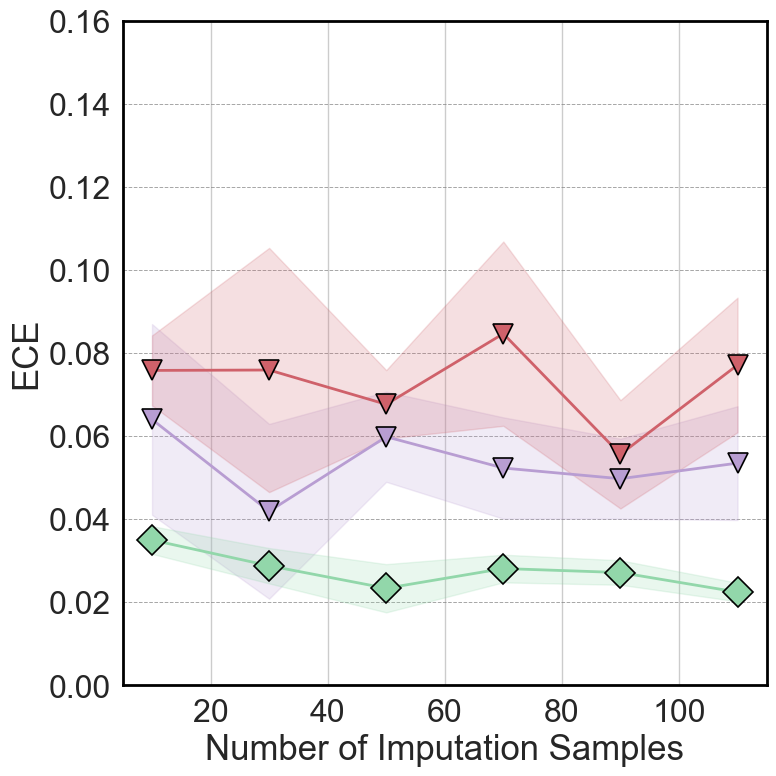

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_MNAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

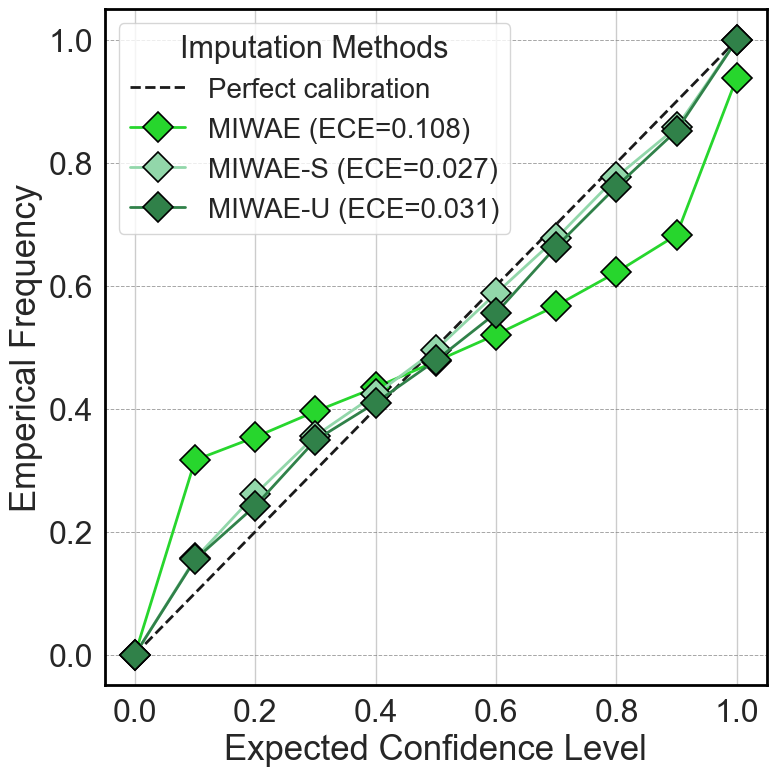

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mnar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

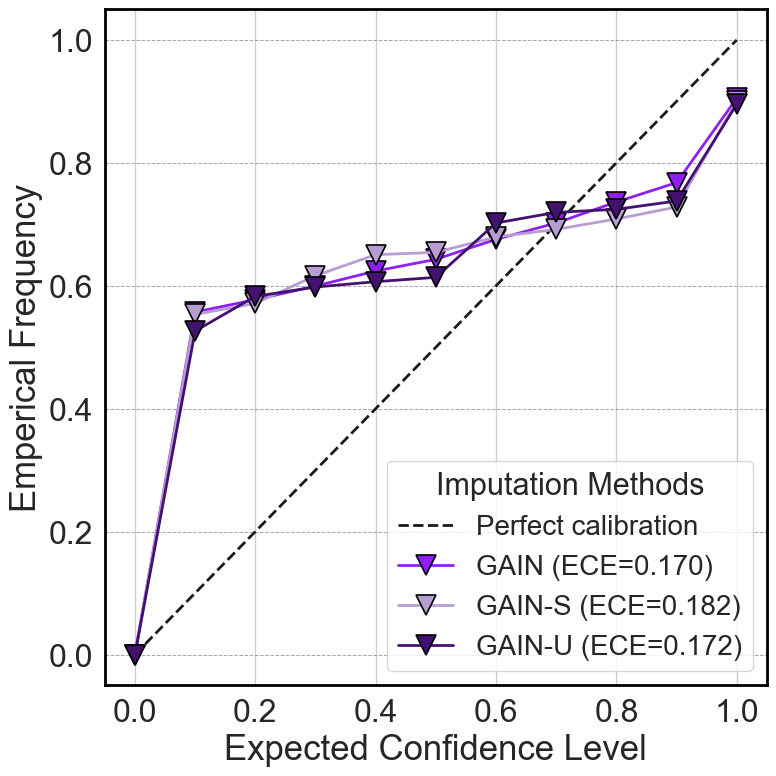

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mnar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



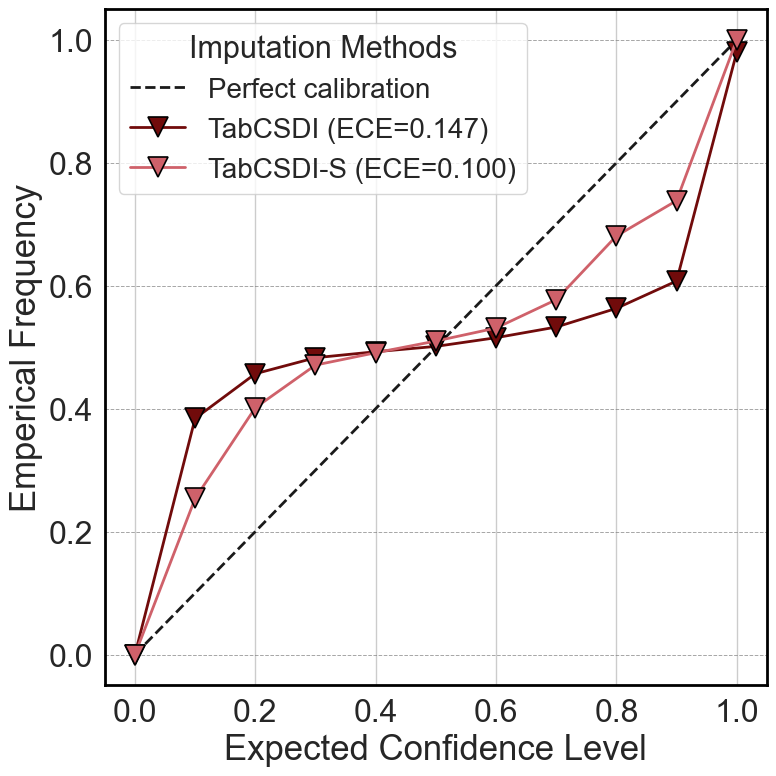

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Energy_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Energy_mnar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()
